In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Packages**

In [12]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Flatten, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import load_model
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

**Read the Dataset**

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Breast Cancer METABRIC.csv')
data.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1,Positve,Positive,2.0,Neutral,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1,Positve,Positive,2.0,Neutral,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1,Positve,Positive,3.0,Neutral,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


**Check dataset Info and drop useless columns**

In [4]:
data.drop(['Patient ID','Relapse Free Status (Months)','Overall Survival (Months)'], axis=1, inplace=True)
data.info()
data.drop_duplicates(inplace=True)
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age at Diagnosis                1985 non-null   float64
 1   Type of Breast Surgery          1955 non-null   object 
 2   Cancer Type                     1985 non-null   object 
 3   Cancer Type Detailed            1985 non-null   object 
 4   Cellularity                     1917 non-null   object 
 5   Chemotherapy                    1980 non-null   object 
 6   Pam50 + Claudin-low subtype     1980 non-null   object 
 7   Cohort                          1985 non-null   int64  
 8   ER status measured by IHC       1942 non-null   object 
 9   ER Status                       1985 non-null   object 
 10  Neoplasm Histologic Grade       1897 non-null   float64
 11  HER2 status measured by SNP6    1980 non-null   object 
 12  HER2 Status                     19

(1985, 31)

**Feature-Target Separation**

In [5]:
x = data.drop('Relapse Free Status', axis=1)
y = data['Relapse Free Status']

**Handling Missing Target Values & Aligning Features**

In [6]:
y = y.dropna()
x = x.loc[y.index]

**Feature Column Categorization & Filtering**

In [7]:
num_col = []
cat_col = []
for i in x.columns:
    if x[i].dtype == 'object':
        cat_col.append(i)
    else:
        num_col.append(i)



e=[]
for i in x.columns:
   if x[i].dtype == 'object':
    if len(data[i].unique()) > 4:
     e.append(i)


g=[]
for i in x.columns:
  if i not in num_col:
    g.append(i)


**Model definition**

In [8]:
def build_model():
    input_c = Input(shape=(1,))
    input_p = Input(shape=(1,))
    input_h = Input(shape=(1,))
    input_t = Input(shape=(1,))
    input_i = Input(shape=(1,))
    input_o = Input(shape=(1,))
    input_3 = Input(shape=(1,))
    input_g = Input(shape=(len(g),))

    embed_c = Embedding(input_dim=11, output_dim=5)(input_c)
    embed_p = Embedding(input_dim=11, output_dim=5)(input_p)
    embed_h = Embedding(input_dim=11, output_dim=5)(input_h)
    embed_t = Embedding(input_dim=11, output_dim=5)(input_t)
    embed_i = Embedding(input_dim=11, output_dim=5)(input_i)
    embed_o = Embedding(input_dim=11, output_dim=5)(input_o)
    embed_3 = Embedding(input_dim=11, output_dim=5)(input_3)
    embed_g = Embedding(input_dim=11, output_dim=5)(input_g)

    fl_c = Flatten()(embed_c)
    fl_p = Flatten()(embed_p)
    fl_h = Flatten()(embed_h)
    fl_t = Flatten()(embed_t)
    fl_i = Flatten()(embed_i)
    fl_o = Flatten()(embed_o)
    fl_3 = Flatten()(embed_3)
    fl_g = Flatten()(embed_g)

    concat = Concatenate()([fl_c, fl_p, fl_h, fl_t, fl_i, fl_o, fl_3, fl_g])

    d1 = Dense(200, activation='relu')(concat)
    d1 = BatchNormalization()(d1)
    d1 = Dropout(0.5)(d1)

    d2 = Dense(200, activation='relu')(d1)
    d2 = BatchNormalization()(d2)
    d2 = Dropout(0.5)(d2)

    d3 = Dense(200, activation='relu')(d2)
    d3 = BatchNormalization()(d3)
    d3 = Dropout(0.5)(d3)

    d4 = Dense(200, activation='relu')(d3)
    d4 = BatchNormalization()(d4)
    d4 = Dropout(0.5)(d4)

    out = Dense(1, activation='sigmoid')(d4)

    model = Model(inputs=[input_c, input_p, input_h, input_t, input_i, input_o, input_3, input_g], outputs=out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

**Stratified K-Fold Cross-Validation Setup**

In [9]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

**Distribution-Based Null Imputation Strategy**

Neoplasm Histologic Grade 88
Lymph nodes examined positive 76
Mutation Count 121
Nottingham prognostic index 1
Tumor Size 26
Tumor Stage 515


array([[<Axes: title={'center': 'Neoplasm Histologic Grade'}>,
        <Axes: title={'center': 'Lymph nodes examined positive'}>],
       [<Axes: title={'center': 'Mutation Count'}>,
        <Axes: title={'center': 'Nottingham prognostic index'}>],
       [<Axes: title={'center': 'Tumor Size'}>,
        <Axes: title={'center': 'Tumor Stage'}>]], dtype=object)

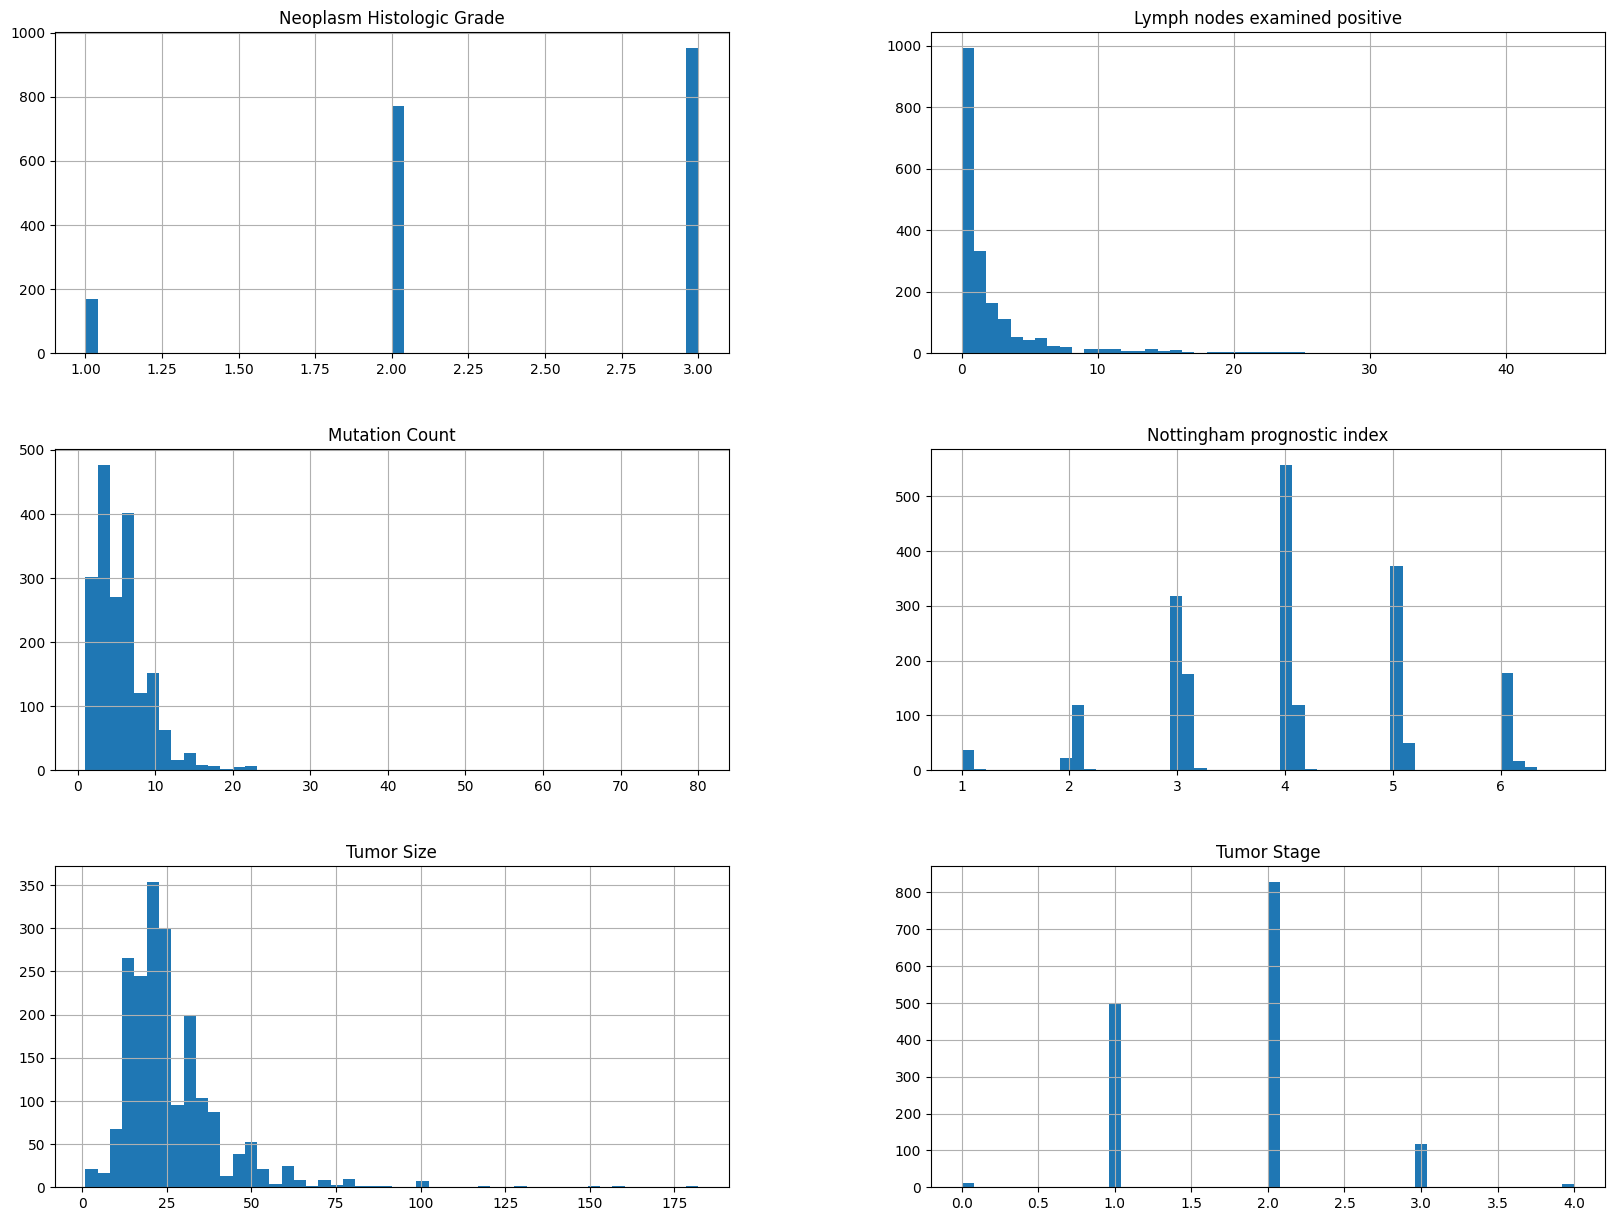

In [10]:

n=[]
for i in x.columns:
  if x[i].dtype != 'object':
    if x[i].isnull().sum() > 0:
      print(i,x[i].isnull().sum())
      n.append(i)



x[n].hist(bins=50, figsize=(20,15))

**Cross-Validation Training & Evaluation Pipeline**

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model


fold_acc = []
fold_f1 = []
fold_recall = []
fold_precision = []
fold_auc = []

best_acc = 0
best_history = None
best_x_test = None
best_y_test = None
best_y_pred_prob = None
best_y_pred = None

for fold, (train_idx, test_idx) in enumerate(skf.split(x, y)):
    print(f"\n Fold {fold+1}")

    x_train = x.iloc[train_idx].copy()
    x_test = x.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    for i in x_train.columns:
        if x_train[i].dtype == 'object':
            if x_train[i].isnull().sum() < 70:
                mode_val = x_train[i].mode()[0]
                x_train[i].fillna(mode_val, inplace=True)
                x_test[i].fillna(mode_val, inplace=True)

    x_train['Primary Tumor Laterality'].fillna('Unknown', inplace=True)
    x_train['3-Gene classifier subtype'].fillna('Unknown', inplace=True)
    x_test['Primary Tumor Laterality'].fillna('Unknown', inplace=True)
    x_test['3-Gene classifier subtype'].fillna('Unknown', inplace=True)


    x_train['Neoplasm Histologic Grade'].fillna(x_train['Neoplasm Histologic Grade'].mode()[0], inplace=True)
    x_train['Tumor Stage'].fillna(x_train['Tumor Stage'].mode()[0], inplace=True)
    x_train['Lymph nodes examined positive'].fillna(x_train['Lymph nodes examined positive'].median(), inplace=True)
    x_train['Mutation Count'].fillna(x_train['Mutation Count'].median(), inplace=True)
    x_train['Nottingham prognostic index'].fillna(x_train['Nottingham prognostic index'].mean(), inplace=True)
    x_train['Tumor Size'].fillna(x_train['Tumor Size'].median(), inplace=True)

    x_test['Neoplasm Histologic Grade'].fillna(x_train['Neoplasm Histologic Grade'].mode()[0], inplace=True)
    x_test['Tumor Stage'].fillna(x_train['Tumor Stage'].mode()[0], inplace=True)
    x_test['Lymph nodes examined positive'].fillna(x_train['Lymph nodes examined positive'].median(), inplace=True)
    x_test['Mutation Count'].fillna(x_train['Mutation Count'].median(), inplace=True)
    x_test['Nottingham prognostic index'].fillna(x_train['Nottingham prognostic index'].mean(), inplace=True)
    x_test['Tumor Size'].fillna(x_train['Tumor Size'].median(), inplace=True)



    d = {'1':1, '2':2, '3':3, '4ER-':3.9, '4ER+':4.1, '5':5, '6':6, '7':7, '8':8, '9':9, '10':10}
    x_train['Integrative Cluster'] = x_train['Integrative Cluster'].map(d).astype('float')
    x_test['Integrative Cluster'] = x_test['Integrative Cluster'].map(d).astype('float')


    for i in x_train.columns:
        if x_train[i].dtype == 'object':
            le = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            x_train[i] = le.fit_transform(x_train[[i]])
            x_test[i] = le.transform(x_test[[i]])


    lbl = LabelEncoder()
    y_train = lbl.fit_transform(y_train).astype('float')
    y_test = lbl.transform(y_test)


    scaler = StandardScaler()
    x_train[num_col] = scaler.fit_transform(x_train[num_col])
    x_test[num_col] = scaler.transform(x_test[num_col])


    x_train_input = [
        x_train['Cancer Type Detailed'].values,
        x_train['Pam50 + Claudin-low subtype'].values,
        x_train['HER2 status measured by SNP6'].values,
        x_train['Tumor Other Histologic Subtype'].values,
        x_train['Integrative Cluster'].values,
        x_train['Oncotree Code'].values,
        x_train['3-Gene classifier subtype'].values,
        x_train[g].values]

    x_test_input = [
        x_test['Cancer Type Detailed'].values,
        x_test['Pam50 + Claudin-low subtype'].values,
        x_test['HER2 status measured by SNP6'].values,
        x_test['Tumor Other Histologic Subtype'].values,
        x_test['Integrative Cluster'].values,
        x_test['Oncotree Code'].values,
        x_test['3-Gene classifier subtype'].values,
        x_test[g].values]


    model = build_model()
    model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy')
    hist= model.fit(x=x_train_input, y=y_train,epochs=35, batch_size=60,validation_data=(x_test_input, y_test),callbacks=[model_checkpoint])
    model.summary()

    model=load_model('best_model.h5')
    y_pred_prob = model.predict(x_test_input, verbose=0)
    y_pred = (y_pred_prob > 0.4).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)

    fold_acc.append(acc)
    fold_f1.append(f1)
    fold_recall.append(recall)
    fold_precision.append(precision)
    fold_auc.append(auc)

    if acc > best_acc:
      best_acc = acc
      best_history = hist
      best_x_test = x_test
      best_y_test = y_test
      best_y_pred = y_pred
      best_y_pred_prob = y_pred_prob

    print(f"Acc: {acc:.4f}, F1: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, AUC: {auc:.4f}")


 Fold 1
Epoch 1/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5380 - loss: 0.9784

27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.5633 - loss: 0.9197 - val_accuracy: 0.5945 - val_loss: 0.6787
Epoch 2/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6963 - loss: 0.6749 - val_accuracy: 0.5945 - val_loss: 0.6605
Epoch 3/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7940 - loss: 0.4999 - val_accuracy: 0.5945 - val_loss: 0.6457
Epoch 4/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8526 - loss: 0.4096 - val_accuracy: 0.5945 - val_loss: 0.6461
Epoch 5/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8859 - loss: 0.3384 - val_accuracy: 0.5945 - val_loss: 0.6381
Epoch 6/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8891 - loss: 0.3136 - val_accuracy: 0.5945 - val_loss: 0.5792
Epoch 7/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8929 - loss: 0.3307 - val_accuracy: 0.5945 - val_loss: 0.5710
Epoch 8/35
14/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9060 - loss: 0.2713 

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8967 - loss: 0.3027 - val_accuracy: 0.6020 - val_loss: 0.5314
Epoch 9/35
16/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9131 - loss: 0.2589 

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9036 - loss: 0.3010 - val_accuracy: 0.8363 - val_loss: 0.5043
Epoch 10/35
16/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9066 - loss: 0.2966 

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9074 - loss: 0.2835 - val_accuracy: 0.9043 - val_loss: 0.4769
Epoch 11/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9036 - loss: 0.3034 - val_accuracy: 0.8917 - val_loss: 0.4629
Epoch 12/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9118 - loss: 0.2924 - val_accuracy: 0.8413 - val_loss: 0.4632
Epoch 13/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9156 - loss: 0.2750 - val_accuracy: 0.8942 - val_loss: 0.4374
Epoch 14/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9181 - loss: 0.2788 - val_accuracy: 0.9043 - val_loss: 0.4243
Epoch 15/35
16/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9060 - loss: 0.2837 

...

 Total params: 457,725 (1.75 MB)

 Trainable params: 152,041 (593.91 KB)

 Non-trainable params: 1,600 (6.25 KB)

 Optimizer params: 304,084 (1.16 MB)

Acc: 0.9242, F1: 0.8966, Recall: 0.8125, Precision: 1.0000, AUC: 0.9309


**Model Evaluation**

In [14]:

print(fold_acc)
print(f"average accuracy: {np.mean(fold_acc)}")
print()
print(fold_f1)
print(f"average f1: {np.mean(fold_f1):.4f}")
print()
print(fold_recall)
print(f"average recall: {np.mean(fold_recall):.4f}")
print()
print(fold_precision)
print(f"average precision: {np.mean(fold_precision):.4f}")
print()
print(fold_auc)
print(f"average auc: {np.mean(fold_auc):.4f}")


[0.9143576826196473, 0.9168765743073047, 0.9193954659949622, 0.9269521410579346, 0.9242424242424242]
average accuracy: 0.9203648576444546

[0.8819444444444444, 0.8858131487889274, 0.8896551724137931, 0.9010238907849829, 0.896551724137931]
average f1: 0.8910

[0.7888198757763976, 0.7950310559006211, 0.8012422360248447, 0.8198757763975155, 0.8125]
average recall: 0.8035

[1.0, 1.0, 1.0, 1.0, 1.0]
average precision: 1.0000

[np.float64(0.9046741762290768), np.float64(0.919241499105169), np.float64(0.9203863564585745), np.float64(0.9357432361301191), np.float64(0.9308792372881356)]
average auc: 0.9222


**Visualization**

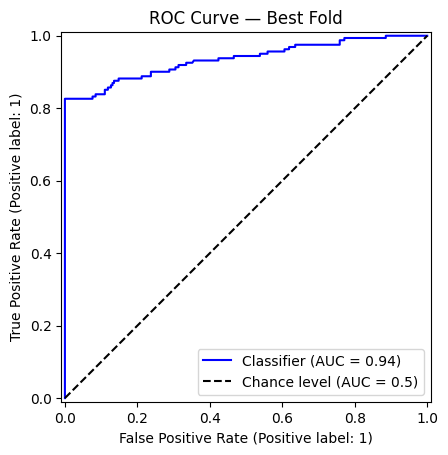

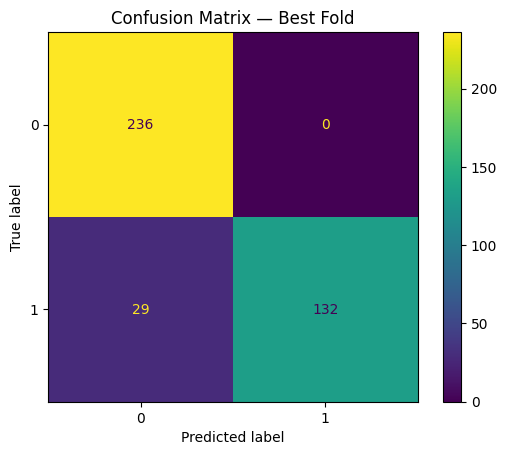

In [15]:
from sklearn.metrics import RocCurveDisplay,ConfusionMatrixDisplay

# ROC Curve
RocCurveDisplay.from_predictions(best_y_test, best_y_pred_prob,color='blue', plot_chance_level=True)
plt.title('ROC Curve — Best Fold')
plt.savefig('Roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()


# ConfusionMatrix
ConfusionMatrixDisplay.from_predictions(best_y_test, best_y_pred)
plt.title('Confusion Matrix — Best Fold')
plt.show()
